In [1]:
#loading python classes and packages
import warnings
warnings.filterwarnings("ignore", message="urllib3 v2 only supports OpenSSL")
warnings.filterwarnings("ignore", category=FutureWarning, message="Series.ravel is deprecated")
import os
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"

import numpy as np
import pandas as pd
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer #loading bert sentence model
from string import punctuation
from nltk.corpus import stopwords
import nltk
from nltk.stem import WordNetLemmatizer
import pickle
from nltk.stem import PorterStemmer
import smote_variants
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.layers import Input, MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Convolution2D
from keras.models import Sequential, load_model, Model
from sklearn.metrics import accuracy_score
from keras.callbacks import ModelCheckpoint
import os

In [2]:
#loading bert and roberta models
roberta = SentenceTransformer('nli-distilroberta-base-v2')
berts = SentenceTransformer('distilbert-base-nli-stsb-mean-tokens')
print("Bert & Roberta Model Loaded")

Bert & Roberta Model Loaded


In [3]:
#define classes to perform NLP operations on text such as removing stop words and symbols
#define object to remove stop words and other text processing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
ps = PorterStemmer()

In [4]:
#define function to clean text by removing stop words and other special symbols
def cleanText(doc):
    tokens = doc.split()
    table = str.maketrans('', '', punctuation)
    tokens = [w.translate(table) for w in tokens]
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [w for w in tokens if not w in stop_words]
    tokens = [word for word in tokens if len(word) > 1]
    tokens = [ps.stem(token) for token in tokens]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = ' '.join(tokens)
    return tokens

In [5]:
#defining global variables to store X and Y training data
X = []
Y = []

In [6]:
#function to read job posting details from given dataset details
def ReadJobData(text_features, labels):
    for i in range(len(text_features)):
        data = str(text_features[i])
        data = data.strip().lower()
        if len(data) > 0:
            data = cleanText(data)
            X.append(data)
            Y.append(labels[i])
            print(str(i)+" "+str(len(X))+" "+str(len(data)))

In [7]:
# loading the latest India-focused training dataset
TRAIN_SAMPLE_SIZE = 5000  # set to None for the full dataset
FORCE_REBUILD_FEATURES = True  # set to False after bert/roberta feature files are created once

dataset1 = pd.read_csv("Dataset/india_training_dataset.csv", low_memory=False).fillna("")
if TRAIN_SAMPLE_SIZE is not None:
    dataset1 = dataset1.sample(TRAIN_SAMPLE_SIZE, random_state=42).reset_index(drop=True)
else:
    dataset1 = dataset1.reset_index(drop=True)

print("Rows selected for training:", len(dataset1))
print(dataset1['fraudulent'].value_counts())
dataset1.head()

Rows selected for training: 5000
fraudulent
0    4544
1     456
Name: count, dtype: int64


,job_id,title,company_name,location,department,salary_range,company_profile,description,requirements,benefits,...,employment_type,required_experience,required_education,industry,function,fraudulent,label,source,source_url,is_indian_market
0,naukri_b69f5b540187877660d644736f8e925f,VB.NET ASP.NET Application Developer,,"Chennai, chennai",Programming & Design,Not Disclosed by Recruiter,,VB.NET ASP.NET Application Developer opportuni...,"mca, billing, php, net asp net, vb.net, asp ne...",,...,,1 - 3 yrs,,"IT-Software, Software Services","IT Software - Application Programming , Mainte...",0,0,naukri_30k_mirror,https://raw.githubusercontent.com/mrmaheshrajp...,True
1,naukri_9c463ec63c31f46dd72bf025dea427a9,Network Data L3 Engineer - Routing & Switching,,"Mumbai, Bengaluru, Chennai",Programming & Design,Not Disclosed by Recruiter,,Network Data L3 Engineer - Routing & Switching...,"ospf, eigrp, vtp, bgp, wireless networking, vl...",,...,,8 - 13 yrs,,IT-Hardware & Networking,"IT Software - Application Programming , Mainte...",0,0,naukri_30k_mirror,https://raw.githubusercontent.com/mrmaheshrajp...,True
2,naukri_94bc0ea677aa5c0d197517bec1f816c7,Java Developer - Delhi,,"Delhi, Delhi NCR",Programming & Design,"4,00,000 - 8,50,000 PA.",,"Java Developer - Delhi opportunity in Delhi, D...","Java, Hibernate, IBATIS, Solr, Javascript, J2E...",,...,,3 - 5 yrs,,"IT-Software, Software Services","IT Software - Application Programming , Mainte...",0,0,naukri_30k_mirror,https://raw.githubusercontent.com/mrmaheshrajp...,True
3,india_scam_1298,Urgent Hiring - Treasury Manager,Confidential Placement Partner,Mumbai,Finance/Audit,Not Disclosed by Recruiter,Fast-track recruiting partner claiming India-w...,Premium placement partner is onboarding candid...,Pay the registration fee by UPI to activate th...,,...,Full-time,3 - 8 yrs,Any Graduate,"FMCG, Foods, Beverage","Accounts , Finance , Tax , Company Secretary ,...",1,1,synthetic_india_scam,local_rule_based_generation,True
4,naukri_ec7486a4421b7d0417906b47bdac71fa,Software Engineer/ Lead/ Architect - Java/ J2EE,,"Bengaluru, Gurgaon, Imphal, Noida",Programming & Design,Not Disclosed by Recruiter,,Software Engineer/ Lead/ Architect - Java/ J2E...,"Java, DevOps, RDBMS, MySQL, J2EE, Webservices,...",,...,,4 - 9 yrs,,"IT-Software, Software Services","IT Software - Application Programming , Mainte...",0,0,naukri_30k_mirror,https://raw.githubusercontent.com/mrmaheshrajp...,True


In [8]:
# old dataset cells removed
dataset2 = None
dataset3 = None

In [9]:
dataset1 = pd.read_csv("Dataset/india_training_dataset.csv", low_memory=False).fillna("")
dataset1 = dataset1.sample(5000, random_state=42)
dataset1


,job_id,title,company_name,location,department,salary_range,company_profile,description,requirements,benefits,...,employment_type,required_experience,required_education,industry,function,fraudulent,label,source,source_url,is_indian_market
967,naukri_b69f5b540187877660d644736f8e925f,VB.NET ASP.NET Application Developer,,"Chennai, chennai",Programming & Design,Not Disclosed by Recruiter,,VB.NET ASP.NET Application Developer opportuni...,"mca, billing, php, net asp net, vb.net, asp ne...",,...,,1 - 3 yrs,,"IT-Software, Software Services","IT Software - Application Programming , Mainte...",0,0,naukri_30k_mirror,https://raw.githubusercontent.com/mrmaheshrajp...,True
15694,naukri_9c463ec63c31f46dd72bf025dea427a9,Network Data L3 Engineer - Routing & Switching,,"Mumbai, Bengaluru, Chennai",Programming & Design,Not Disclosed by Recruiter,,Network Data L3 Engineer - Routing & Switching...,"ospf, eigrp, vtp, bgp, wireless networking, vl...",,...,,8 - 13 yrs,,IT-Hardware & Networking,"IT Software - Application Programming , Mainte...",0,0,naukri_30k_mirror,https://raw.githubusercontent.com/mrmaheshrajp...,True
21027,naukri_94bc0ea677aa5c0d197517bec1f816c7,Java Developer - Delhi,,"Delhi, Delhi NCR",Programming & Design,"4,00,000 - 8,50,000 PA.",,"Java Developer - Delhi opportunity in Delhi, D...","Java, Hibernate, IBATIS, Solr, Javascript, J2E...",,...,,3 - 5 yrs,,"IT-Software, Software Services","IT Software - Application Programming , Mainte...",0,0,naukri_30k_mirror,https://raw.githubusercontent.com/mrmaheshrajp...,True
37480,india_scam_1298,Urgent Hiring - Treasury Manager,Confidential Placement Partner,Mumbai,Finance/Audit,Not Disclosed by Recruiter,Fast-track recruiting partner claiming India-w...,Premium placement partner is onboarding candid...,Pay the registration fee by UPI to activate th...,,...,Full-time,3 - 8 yrs,Any Graduate,"FMCG, Foods, Beverage","Accounts , Finance , Tax , Company Secretary ,...",1,1,synthetic_india_scam,local_rule_based_generation,True
17000,naukri_ec7486a4421b7d0417906b47bdac71fa,Software Engineer/ Lead/ Architect - Java/ J2EE,,"Bengaluru, Gurgaon, Imphal, Noida",Programming & Design,Not Disclosed by Recruiter,,Software Engineer/ Lead/ Architect - Java/ J2E...,"Java, DevOps, RDBMS, MySQL, J2EE, Webservices,...",,...,,4 - 9 yrs,,"IT-Software, Software Services","IT Software - Application Programming , Mainte...",0,0,naukri_30k_mirror,https://raw.githubusercontent.com/mrmaheshrajp...,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28147,naukri_a967d22fdd495aae80181df4025a814f,Salary Not On Time Come Join & Forget Salary I...,,Kolkata,Voice,Not Disclosed by Recruiter,,Salary Not On Time Come Join & Forget Salary I...,"Outbound, Antivirus, Technical support, proces...",,...,,0 - 1 yrs,,"IT-Software, Software Services","ITES , BPO , KPO , LPO , Customer Service , Op...",0,0,naukri_30k_mirror,https://raw.githubusercontent.com/mrmaheshrajp...,True
7646,naukri_73f932dcffeeb3e2b6efa0c01259da4e,PROJECT SALES- ELECTRICAL/ SR. ENGINEER,,Hyderabad,Corporate Sales,Not Disclosed by Recruiter,,PROJECT SALES- ELECTRICAL/ SR. ENGINEER opport...,"Market analysis, Project sales, Value engineer...",,...,,5 - 10 yrs,,"Real Estate, Property","Sales , Retail , Business Development",0,0,naukri_30k_mirror,https://raw.githubusercontent.com/mrmaheshrajp...,True
36651,india_scam_466,Urgent Hiring - AR Caller,Confidential Placement Partner,"Hyderabad, Hyderabad",Voice,Not Disclosed by Recruiter,Fast-track recruiting partner claiming India-w...,Premium placement partner is onboarding candid...,Pay the registration fee by UPI to activate th...,,...,Full-time,1 - 4 yrs,Any Graduate,"BPO, Call Centre, ITeS","ITES , BPO , KPO , LPO , Customer Service , Op...",1,1,synthetic_india_scam,local_rule_based_generation,True
36042,17684,Assistant Accountant/immediate start,,"AU, NSW, Sydney",,25000-30000,,Our organisation is seeking students / graduat...,Requirements: You must have commenced either y...

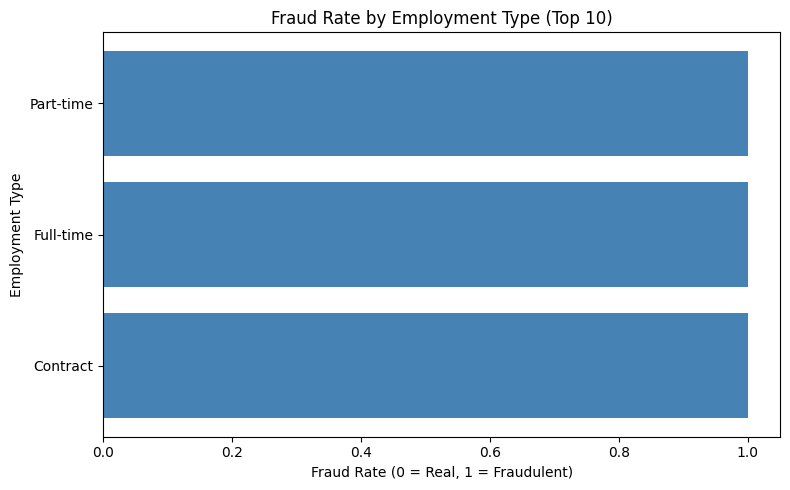

In [10]:
#plot Fraudulent job with respective to employment type
emp_fraud = (
    dataset1[dataset1["employment_type"] != ""]
    .groupby("employment_type")["fraudulent"]
    .agg(fraud_rate="mean", count="count")
    .query("count >= 5")
    .sort_values("fraud_rate", ascending=True)
    .tail(10)
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(emp_fraud.index, emp_fraud["fraud_rate"], color="steelblue")
ax.set_xlabel("Fraud Rate (0 = Real, 1 = Fraudulent)")
ax.set_ylabel("Employment Type")
ax.set_title("Fraud Rate by Employment Type (Top 10)")
plt.tight_layout()
plt.show()
plt.close()


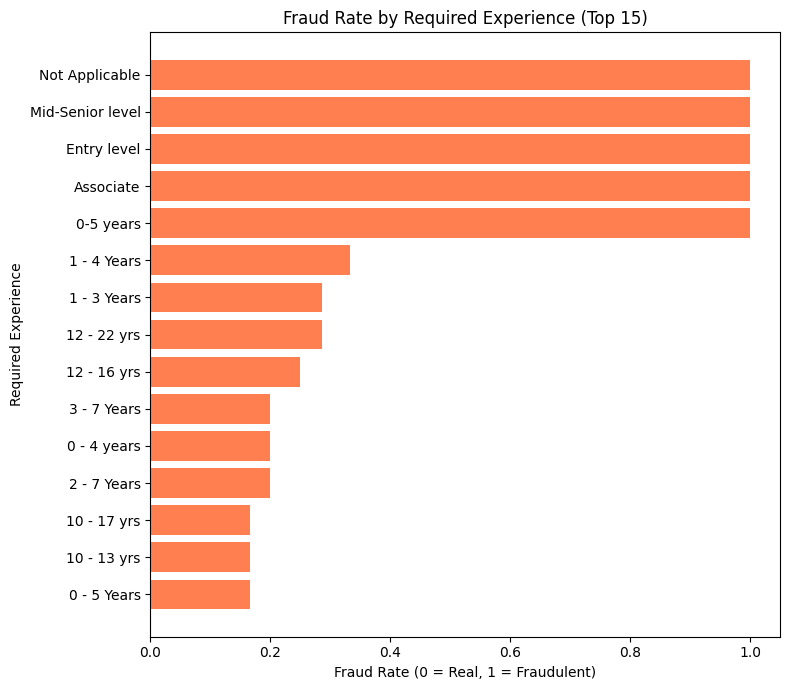

In [11]:
#plot Fraudulent job with respective to required experience
exp_fraud = (
    dataset1[dataset1["required_experience"] != ""]
    .groupby("required_experience")["fraudulent"]
    .agg(fraud_rate="mean", count="count")
    .query("count >= 5")
    .sort_values("fraud_rate", ascending=True)
    .tail(15)
)
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(exp_fraud.index, exp_fraud["fraud_rate"], color="coral")
ax.set_xlabel("Fraud Rate (0 = Real, 1 = Fraudulent)")
ax.set_ylabel("Required Experience")
ax.set_title("Fraud Rate by Required Experience (Top 15)")
plt.tight_layout()
plt.show()
plt.close()


In [12]:
# reading job details from the latest India-focused dataset and building embeddings
cache_files_exist = all(
    os.path.exists(path)
    for path in ["model/X.npy", "model/Y.npy", "model/bert_X.npy", "model/roberta_X.npy"]
)

if (not FORCE_REBUILD_FEATURES) and cache_files_exist:
    X = np.load("model/X.npy", allow_pickle=True)
    Y = np.load("model/Y.npy")
    bert_X = np.load("model/bert_X.npy")
    roberta_X = np.load("model/roberta_X.npy")
else:
    X = []
    Y = []
    d1_desc = dataset1['description'].astype(str).to_numpy()
    d1_label = dataset1['fraudulent'].astype(int).to_numpy()

    ReadJobData(d1_desc, d1_label)

    X = np.asarray(X)
    Y = np.asarray(Y)

    np.save("model/X.npy", X)
    np.save("model/Y.npy", Y)

    bert_X = np.asarray(berts.encode(list(X), batch_size=64, show_progress_bar=True))
    np.save("model/bert_X.npy", bert_X)

    embeddings = roberta.encode(list(X), batch_size=32, show_progress_bar=True, convert_to_tensor=True)
    roberta_X = embeddings.cpu().numpy() if hasattr(embeddings, 'cpu') else embeddings.numpy()
    np.save("model/roberta_X.npy", roberta_X)

print("Dataset Loading & Cleaning Completed")
print("Clean text shape =", X.shape)
print("BERT shape =", bert_X.shape)
print("ROBERTA shape =", roberta_X.shape)
print("Label shape =", Y.shape)

0 1 386
1 2 346
2 3 328
3 4 189
4 5 376
5 6 328
6 7 311
7 8 283
8 9 312
9 10 292
10 11 336
11 12 366
12 13 385
13 14 392
14 15 365
15 16 354
16 17 408
17 18 434
18 19 208
19 20 353
20 21 212
21 22 196
22 23 309
23 24 268
24 25 379
25 26 396
26 27 313
27 28 194
28 29 77
29 30 361
30 31 224
31 32 381
32 33 206
33 34 449
34 35 324
35 36 376
36 37 391
37 38 337
38 39 355
39 40 215
40 41 336
41 42 343
42 43 371
43 44 318
44 45 364
45 46 381
46 47 312
47 48 375
48 49 385
49 50 369
50 51 190
51 52 349
52 53 359
53 54 342
54 55 351
55 56 367
56 57 403
57 58 355
58 59 315
59 60 293
60 61 352
61 62 334
62 63 359
63 64 186
64 65 194
65 66 398
66 67 212
67 68 397
68 69 340
69 70 329
70 71 207
71 72 270
72 73 292
73 74 405
74 75 350
75 76 421
76 77 287
77 78 320
78 79 382
79 80 192
80 81 399
81 82 211
82 83 167
83 84 393
84 85 403
85 86 433
86 87 215
87 88 258
88 89 335
89 90 412
90 91 325
91 92 331
92 93 208
93 94 190
94 95 356
95 96 335
96 97 349
97 98 294
98 99 235
99 100 380
100 101 321
101 102

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Dataset Loading & Cleaning Completed
Clean text shape = (5000,)
BERT shape = (5000, 768)
ROBERTA shape = (5000, 768)
Label shape = (5000,)


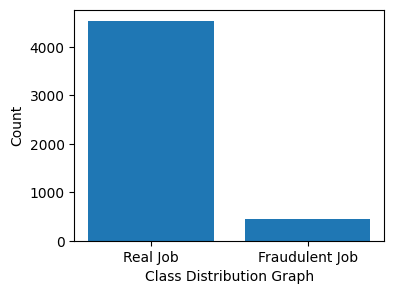

In [13]:
#Binary label calculation based on sub-network similary
#visualizing class labels count found in dataset
names, count = np.unique(Y, return_counts = True)
labels = ['Real Job', 'Fraudulent Job']
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.figure(figsize = (4, 3)) 
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Class Distribution Graph")
plt.ylabel("Count")
plt.show()

In [14]:
#dataset preprocessing like shuffling and splitting both bert and roberta embedding into train and test
indices = np.arange(bert_X.shape[0])
np.random.shuffle(indices)
bert_X = bert_X[indices]
roberta_X = roberta_X[indices]
Y = Y[indices]

bert_X_train, bert_X_test, bert_y_train, bert_y_test = train_test_split(
    bert_X, Y, test_size=0.2, random_state=42, stratify=Y
)
roberta_X_train, roberta_X_test, roberta_y_train, roberta_y_test = train_test_split(
    roberta_X, Y, test_size=0.2, random_state=42, stratify=Y
)

bert_y_train = to_categorical(bert_y_train)
bert_y_test = to_categorical(bert_y_test)
roberta_y_train = to_categorical(roberta_y_train)
roberta_y_test = to_categorical(roberta_y_test)
print("Dataset Train & Test Split Details")
print("80% BERT features used to train algorithms : "+str(bert_X_train.shape[0]))
print("20% BERT features used to test algorithms : "+str(bert_X_test.shape[0]))
print("80% ROBERTA features used to train algorithms : "+str(roberta_X_train.shape[0]))
print("20% ROBERTA features used to test algorithms : "+str(roberta_X_test.shape[0]))

Dataset Train & Test Split Details
80% BERT features used to train algorithms : 4000
20% BERT features used to test algorithms : 1000
80% ROBERTA features used to train algorithms : 4000
20% ROBERTA features used to test algorithms : 1000


In [15]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [16]:
#function to calculate accuracy and other metrics
def calculateMetrics(algorithm, predict, y_test):
    a = accuracy_score(y_test, predict) * 100
    p = precision_score(y_test, predict, average='macro', zero_division=0) * 100
    r = recall_score(y_test, predict, average='macro', zero_division=0) * 100
    f = f1_score(y_test, predict, average='macro', zero_division=0) * 100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  :  "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FScore    : "+str(f))
    conf_matrix = confusion_matrix(y_test, predict)
    plt.figure(figsize=(4, 3))
    ax = sns.heatmap(conf_matrix, xticklabels=labels, yticklabels=labels, annot=True, cmap="viridis", fmt="g")
    ax.set_ylim([0, len(labels)])
    plt.title(algorithm+" Confusion matrix")
    plt.xticks(rotation=90)
    plt.ylabel('True class')
    plt.xlabel('Predicted class')
    plt.tight_layout()
    plt.show()

Propose BERT + Actual Data Accuracy  :  90.9
Propose BERT + Actual Data Precision : 45.45
Propose BERT + Actual Data Recall    : 50.0
Propose BERT + Actual Data FScore    : 47.61655316919853


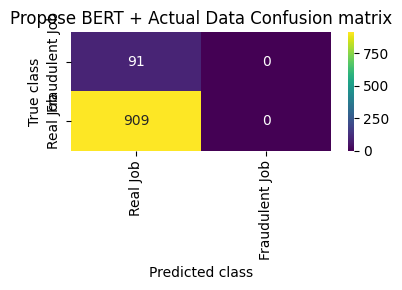

In [17]:
#training actual BERT features without SMOBD using Neural Network
bert_cls = Sequential([
    Input(shape=(bert_X_train.shape[1],)),
    Dense(50),
    Activation('relu'),
    Dropout(0.3),
    Dense(50),
    Activation('relu'),
    Dropout(0.3),
    Dense(bert_y_train.shape[1], activation='softmax')
])
bert_cls.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
if os.path.exists("model/bert_cls.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/bert_cls.hdf5', verbose=1, save_best_only=True)
    bert_cls.fit(bert_X_train, bert_y_train, batch_size=32, epochs=10, validation_data=(bert_X_test, bert_y_test), callbacks=[model_check_point], verbose=1)
else:
    bert_cls.load_weights("model/bert_cls.hdf5")
predict = bert_cls.predict(bert_X_test, verbose=0)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(bert_y_test, axis=1)
calculateMetrics("Propose BERT + Actual Data", predict, y_test1)

Propose ROBERTA + Actual Data Accuracy  :  90.9
Propose ROBERTA + Actual Data Precision : 45.45
Propose ROBERTA + Actual Data Recall    : 50.0
Propose ROBERTA + Actual Data FScore    : 47.61655316919853


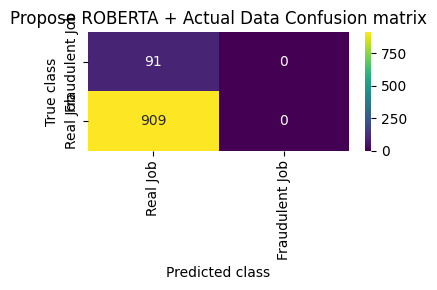

In [18]:
#training roberta actual data using neural network
roberta_cls = Sequential([
    Input(shape=(roberta_X_train.shape[1],)),
    Dense(50),
    Activation('relu'),
    Dropout(0.3),
    Dense(50),
    Activation('relu'),
    Dropout(0.3),
    Dense(roberta_y_train.shape[1], activation='softmax')
])
roberta_cls.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
if os.path.exists("model/roberta_cls.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/roberta_cls.hdf5', verbose=1, save_best_only=True)
    roberta_cls.fit(roberta_X_train, roberta_y_train, batch_size=32, epochs=10, validation_data=(roberta_X_test, roberta_y_test), callbacks=[model_check_point], verbose=1)
else:
    roberta_cls.load_weights("model/roberta_cls.hdf5")
predict = roberta_cls.predict(roberta_X_test, verbose=0)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(roberta_y_test, axis=1)
calculateMetrics("Propose ROBERTA + Actual Data", predict, y_test1)

In [19]:
#now applying SMOBD SMOTE oversampling algorithm to generate synthectic data for under sample classes
print("Total records exists in dataset before applying SMOBD SMOTE = "+str(bert_X_train.shape[0]))
oversampler = smote_variants.SMOBD()
bert_X_train, bert_y_train = oversampler.sample(bert_X_train, np.argmax(bert_y_train, axis=1))
oversampler = smote_variants.SMOBD()
roberta_X_train, roberta_y_train = oversampler.sample(roberta_X_train, np.argmax(roberta_y_train, axis=1))
bert_y_train = to_categorical(bert_y_train)
roberta_y_train = to_categorical(roberta_y_train)
print("Total records exists in dataset after applying SMOBD SMOTE = "+str(bert_X_train.shape[0]))

2026-06-02 20:35:36,252:INFO:SMOBD: Running sampling via ('SMOBD', "{'proportion': 1.0, 'eta1': 0.5, 't': 1.8, 'min_samples': 5, 'max_eps': 1.0, 'n_jobs': 1, 'random_state': None}")


Total records exists in dataset before applying SMOBD SMOTE = 4000


2026-06-02 20:35:40,454:INFO:SMOBD: Running sampling via ('SMOBD', "{'proportion': 1.0, 'eta1': 0.5, 't': 1.8, 'min_samples': 5, 'max_eps': 1.0, 'n_jobs': 1, 'random_state': None}")


Total records exists in dataset after applying SMOBD SMOTE = 7270


Propose BERT + SMOBD SMOTE Data Accuracy  :  93.60000000000001
Propose BERT + SMOBD SMOTE Data Precision : 88.49156896157074
Propose BERT + SMOBD SMOTE Data Recall    : 68.29628017746829
Propose BERT + SMOBD SMOTE Data FScore    : 74.04451365907468


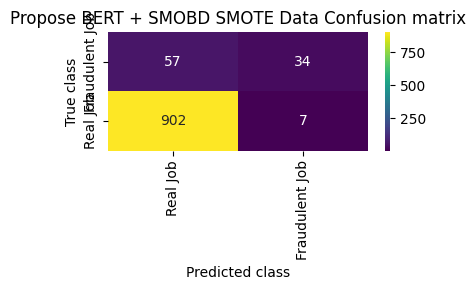

In [20]:
#training BERT with SMOBD SMOTE oversampling records
smobd_bert_cls = Sequential([
    Input(shape=(bert_X_train.shape[1],)),
    Dense(50),
    Activation('relu'),
    Dropout(0.3),
    Dense(50),
    Activation('relu'),
    Dropout(0.3),
    Dense(bert_y_train.shape[1], activation='softmax')
])
smobd_bert_cls.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
if os.path.exists("model/smobd_bert_cls.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/smobd_bert_cls.hdf5', verbose=1, save_best_only=True)
    smobd_bert_cls.fit(bert_X_train, bert_y_train, batch_size=32, epochs=10, validation_data=(bert_X_test, bert_y_test), callbacks=[model_check_point], verbose=1)
else:
    smobd_bert_cls.load_weights("model/smobd_bert_cls.hdf5")
predict = smobd_bert_cls.predict(bert_X_test, verbose=0)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(bert_y_test, axis=1)
calculateMetrics("Propose BERT + SMOBD SMOTE Data", predict, y_test1)

Propose ROBERTA + SMOBD SMOTE Data Accuracy  :  87.4
Propose ROBERTA + SMOBD SMOTE Data Precision : 59.13020348450592
Propose ROBERTA + SMOBD SMOTE Data Recall    : 57.46926340985746
Propose ROBERTA + SMOBD SMOTE Data FScore    : 58.15399330463893


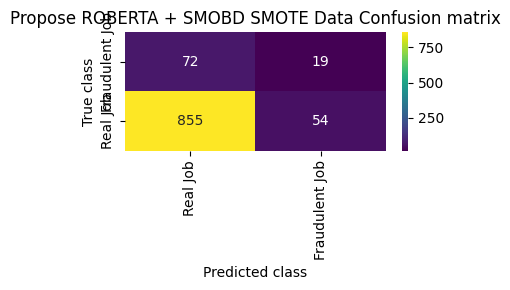

In [21]:
#training ROBERTA with SMOBD SMOTE oversampling records
smobd_roberta_cls = Sequential([
    Input(shape=(roberta_X_train.shape[1],)),
    Dense(50),
    Activation('relu'),
    Dropout(0.3),
    Dense(50),
    Activation('relu'),
    Dropout(0.3),
    Dense(roberta_y_train.shape[1], activation='softmax')
])
smobd_roberta_cls.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
if os.path.exists("model/smobd_roberta_cls.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/smobd_roberta_cls.hdf5', verbose=1, save_best_only=True)
    smobd_roberta_cls.fit(roberta_X_train, roberta_y_train, batch_size=32, epochs=10, validation_data=(roberta_X_test, roberta_y_test), callbacks=[model_check_point], verbose=1)
else:
    smobd_roberta_cls.load_weights("model/smobd_roberta_cls.hdf5")
predict = smobd_roberta_cls.predict(roberta_X_test, verbose=0)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(roberta_y_test, axis=1)
calculateMetrics("Propose ROBERTA + SMOBD SMOTE Data", predict, y_test1)

Extension BERT + SMOBD SMOTE + CNN2D Accuracy  :  88.5
Extension BERT + SMOBD SMOTE + CNN2D Precision : 64.07608695652173
Extension BERT + SMOBD SMOTE + CNN2D Recall    : 62.52432935601253
Extension BERT + SMOBD SMOTE + CNN2D FScore    : 63.230474582665884


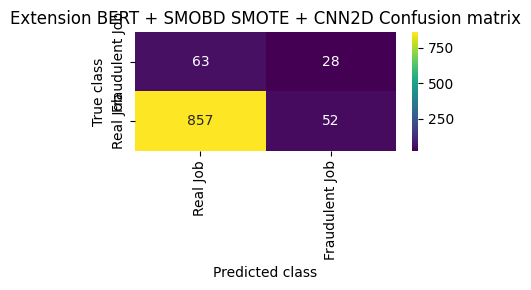

In [22]:
#training BERT SMOBD SMOTE data using extension CNN2D algorithm
bert_X_train = np.reshape(bert_X_train, (bert_X_train.shape[0], 32, 24, 1))
bert_X_test = np.reshape(bert_X_test, (bert_X_test.shape[0], 32, 24, 1))
extension_cnn2d = Sequential([
    Input(shape=(bert_X_train.shape[1], bert_X_train.shape[2], bert_X_train.shape[3])),
    Convolution2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Convolution2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(units=bert_y_train.shape[1], activation='softmax')
])
extension_cnn2d.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
if os.path.exists("model/cnn2d_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn2d_weights.hdf5', verbose=1, save_best_only=True)
    hist = extension_cnn2d.fit(bert_X_train, bert_y_train, batch_size=32, epochs=10, validation_data=(bert_X_test, bert_y_test), callbacks=[model_check_point], verbose=1)
else:
    extension_cnn2d.load_weights("model/cnn2d_weights.hdf5")
predict = extension_cnn2d.predict(bert_X_test, verbose=0)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(bert_y_test, axis=1)
calculateMetrics("Extension BERT + SMOBD SMOTE + CNN2D", predict, y_test1)

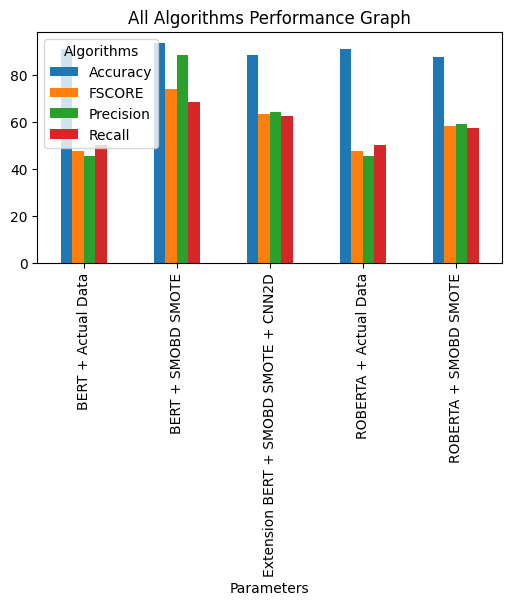

In [23]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['BERT + Actual Data','Accuracy',accuracy[0]],['BERT + Actual Data','Precision',precision[0]],['BERT + Actual Data','Recall',recall[0]],['BERT + Actual Data','FSCORE',fscore[0]],
                   ['ROBERTA + Actual Data','Accuracy',accuracy[1]],['ROBERTA + Actual Data','Precision',precision[1]],['ROBERTA + Actual Data','Recall',recall[1]],['ROBERTA + Actual Data','FSCORE',fscore[1]],
                   ['BERT + SMOBD SMOTE','Accuracy',accuracy[2]],['BERT + SMOBD SMOTE','Precision',precision[2]],['BERT + SMOBD SMOTE','Recall',recall[2]],['BERT + SMOBD SMOTE','FSCORE',fscore[2]],
                   ['ROBERTA + SMOBD SMOTE','Accuracy',accuracy[3]],['ROBERTA + SMOBD SMOTE','Precision',precision[3]],['ROBERTA + SMOBD SMOTE','Recall',recall[3]],['ROBERTA + SMOBD SMOTE','FSCORE',fscore[3]],
                   ['Extension BERT + SMOBD SMOTE + CNN2D','Accuracy',accuracy[4]],['Extension BERT + SMOBD SMOTE + CNN2D','Precision',precision[4]],['Extension BERT + SMOBD SMOTE + CNN2D','Recall',recall[4]],['Extension BERT + SMOBD SMOTE + CNN2D','FSCORE',fscore[4]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot(index="Parameters", columns="Algorithms", values="Value").plot(kind='bar', figsize=(6, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [24]:
#display all algorithm performnace
algorithms = ['BERT + Actual Data', 'ROBERTA + Actual Data', 'BERT + SMOBD SMOTE', 'ROBERTA + SMOBD SMOTE',
             'Extension BERT + SMOBD SMOTE + CNN2D']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,BERT + Actual Data,90.9,45.450000,50.000000,47.616553
1,ROBERTA + Actual Data,90.9,45.450000,50.000000,47.616553
2,BERT + SMOBD SMOTE,93.6,88.491569,68.296280,74.044514
3,ROBERTA + SMOBD SMOTE,87.4,59.130203,57.469263,58.153993
4,Extension BERT + SMOBD SMOTE + CNN2D,88.5,64.076087,62.524329,63.230475


In [25]:
#function to read test data and then predict whether job is real or fraud
test_data = pd.read_csv("Dataset/testData.csv")
data = test_data['description'].astype(str).to_numpy()
temp = []
for i in range(len(data)):
    text = data[i].strip().lower()
    text = cleanText(text)
    temp.append(text)
bert_encode = berts.encode(temp, batch_size=64, show_progress_bar=True)
bert_encode = np.reshape(bert_encode, (bert_encode.shape[0], 32, 24, 1))
predict = extension_cnn2d.predict(bert_encode, verbose=0)
for i in range(len(predict)):
    pred = np.argmax(predict[i])
    print("Job Details = "+data[i])
    print("Predicted Job Type ====> "+labels[pred])
    print()

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Job Details = Sound Experience in Android Development of over 2 yearsJob Responsibilities:1. Developing Android mobile platform Application.2. Outstanding problem solving, debugging, searching skills.3. Quick, effective, turnaround of high quality code.
Predicted Job Type ====> Real Job

Job Details = Axelerant lives and breathes open source through contributing code, events participation, and sharing freely. Our location independent, yet engaged work culture allows you great freedom to get things done in a low stress environment. We’re constantly improving agile policies and processes based upon weekly feedback. These traits serve as the glue that binds our distributed teams together across eleven cities and various continents.We have our own and collaborate with some of the world's top Drupalers. Further, we work closely with well respected partner companies like Acquia. Amazingly, our team has built boring and awesome stuff with a 100% on-time delivery record.What’s stopping you fro

In [26]:
# Run the actual Flask application after training
# This uses app.py and the updated templates instead of the old notebook-only demo routes.

In [27]:
from app import app as trained_app

In [28]:
# Start this after training finishes.
# Login with admin / admin once the server opens.

In [ ]:
trained_app.run(host="127.0.0.1", port=5003, debug=False, use_reloader=False)

 * Serving Flask app 'app'
 * Debug mode: off


 * Running on http://127.0.0.1:5003
Press CTRL+C to quit
